### Linear Regression

In [ ]:
import numpy as np
from google.colab import drive
from matplotlib import pyplot as plt
from sklearn import datasets

# predict meaure of diabetes advancement
X, y = datasets.load_diabetes(return_X_y=True, as_frame=True, scaled=True) # what does scaling do?

print('X')
print(X)
print('y')
print(y)

print('X.mean')
print(X.mean(axis=0))
print('X.std')
print(X.std(axis=0))

print('y: mean={:0.1f}  std={:0.2f}'.format(y.mean(), y.std()))  # std gives us a baseline

# split into train, val, test sets
X_train = X[:300]
y_train = y[:300]
X_val = X[300:370]
y_val = y[300:370]
X_test = X[370:]
y_test = y[370:]



X
          age       sex       bmi        bp        s1        s2        s3  \
0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
..        ...       ...       ...       ...       ...       ...       ...   
437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   

           s4        s5        s6  
0   -0.002592  0.019907 -0.017646  
1

age: 23.201
sex: -65.987
bmi: 258.908
bp: 163.882
s1: 15.045
s2: -21.199
s3: -130.241
s4: 109.862
s5: 237.485
s6: 117.024
Ridge: RMSE = 56.1


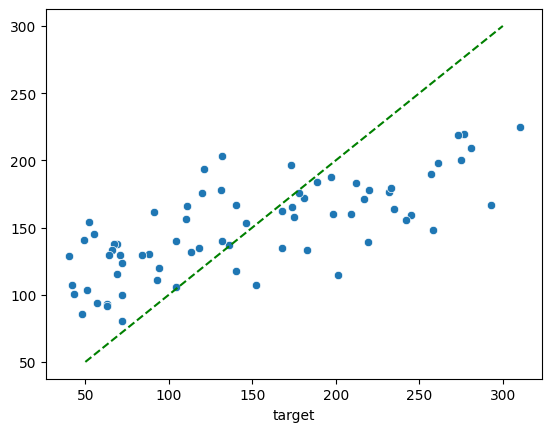

In [ ]:
# Linear regression with L2 regularization (Ridge)

from sklearn.linear_model import Ridge
import seaborn as sns

model = Ridge()
model.fit(X_train, y_train)
for i in range(len(X_train.columns)):
  print('{}: {:0.3f}'.format(X_train.columns[i], model.coef_[i]))


y_pred = model.predict(X_test)

# plot
ax = sns.scatterplot(x=y_test,y=y_pred)   # why is it under-predicting for low values and over-predicing for high?
ax.plot([50, 300], [50, 300], '--g')

rmse = np.sqrt(np.mean((y_pred-y_test)**2))
print('Ridge: RMSE = {:.1f}'.format(rmse))

age: 0.000
sex: -0.000
bmi: 359.220
bp: 0.000
s1: 0.000
s2: 0.000
s3: -0.000
s4: 0.000
s5: 336.889
s6: 0.000
Lasso: RMSE = 58.9


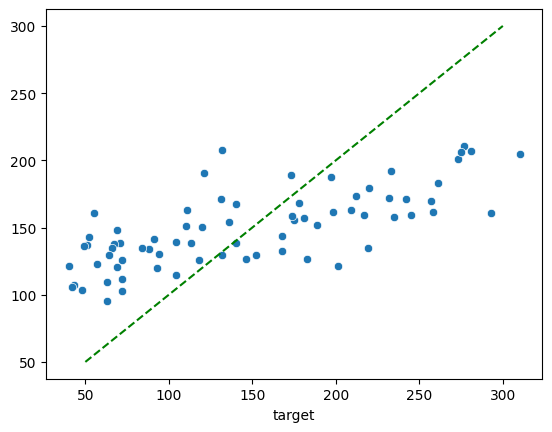

In [ ]:
# Linear regression with L1 regularization (Lasso)

from sklearn.linear_model import Lasso
import seaborn as sns

model = Lasso()
model.fit(X_train, y_train)
for i in range(len(X_train.columns)):
  print('{}: {:0.3f}'.format(X_train.columns[i], model.coef_[i]))


y_pred = model.predict(X_test)
ax = sns.scatterplot(x=y_test,y=y_pred)
ax.plot([50, 300], [50, 300], '--g')
rmse = np.sqrt(np.mean((y_pred-y_test)**2))
print('Lasso: RMSE = {:.1f}'.format(rmse))  # so it's worse, but more informative in some ways

alpha=0.0312: Val RMSE = 55.9
alpha=0.0625: Val RMSE = 55.6
alpha=0.1250: Val RMSE = 55.1
alpha=0.2500: Val RMSE = 54.8
alpha=0.5000: Val RMSE = 55.2
alpha=1.0000: Val RMSE = 56.9
alpha=2.0000: Val RMSE = 60.2
alpha=4.0000: Val RMSE = 64.3


Text(0, 0.5, 'RMSE')

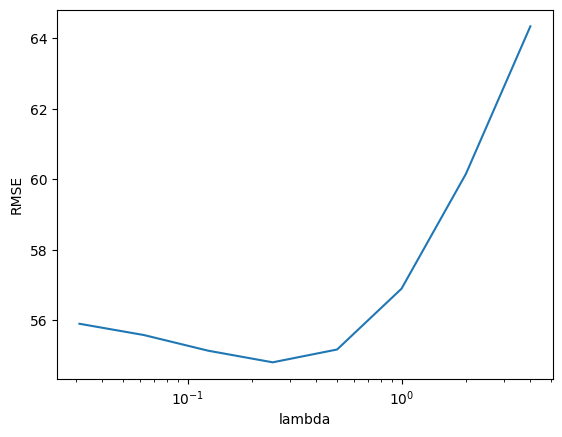

In [ ]:
# Select regularization parameter using validation set (try using Lasso and Ridge)
alphas = [1/32, 1/16, 1/8, 0.25, 0.5, 1, 2, 4]
rmse = np.zeros(len(alphas),)
i = 0
for i in range(len(alphas)):
  model = Ridge(alpha=alphas[i])
  model.fit(X_train, y_train)
  y_pred = model.predict(X_val)
  rmse[i] = np.sqrt(np.mean((y_pred-y_val)**2))
  print('alpha={:0.4f}: Val RMSE = {:.1f}'.format(alphas[i], rmse[i]))

plt.semilogx(alphas, rmse)
plt.xlabel('lambda')
plt.ylabel('RMSE')

Best alpha: 0.2500
Ridge
age: 4.590
sex: -167.307
bmi: 422.929
bp: 237.774
s1: -21.001
s2: -96.229
s3: -167.338
s4: 122.322
s5: 383.509
s6: 133.388
Test RMSE = 51.0
 
Lasso
age: -0.000
sex: -51.095
bmi: 519.321
bp: 160.788
s1: -0.000
s2: -0.000
s3: -118.583
s4: 0.000
s5: 497.733
s6: 18.756
Test RMSE = 50.8


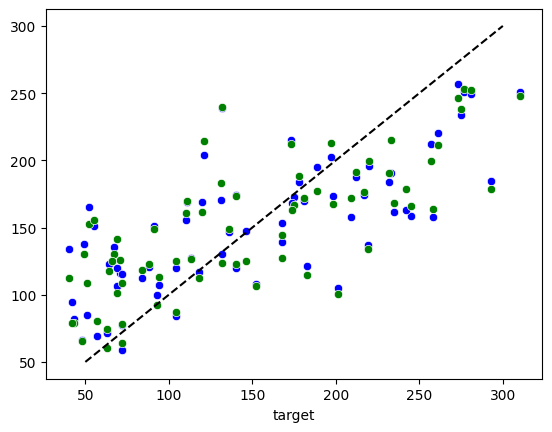

In [ ]:
best_alpha = alphas[np.argmin(rmse)]
print('Best alpha: {:0.4f}'.format(best_alpha))

print('Ridge')
model = Ridge(alpha=best_alpha)
model.fit(X_train, y_train)
for i in range(len(X_train.columns)):
  print('{}: {:0.3f}'.format(X_train.columns[i], model.coef_[i]))

y_pred = model.predict(X_test)
sns.scatterplot(x=y_test,y=y_pred, color='b')
rmse_test = np.sqrt(np.mean((y_pred-y_test)**2))
print('Test RMSE = {:.1f}'.format(rmse_test))

print(' ')
print('Lasso')
model = Lasso(alpha=best_alpha)
model.fit(X_train, y_train)
for i in range(len(X_train.columns)):
  print('{}: {:0.3f}'.format(X_train.columns[i], model.coef_[i]))

y_pred = model.predict(X_test)
sns.scatterplot(x=y_test,y=y_pred, color='g')
plt.plot([50, 300], [50, 300], '--k')
rmse_test = np.sqrt(np.mean((y_pred-y_test)**2))
print('Test RMSE = {:.1f}'.format(rmse_test))

(9,)


Text(0.5, 0, 'lambda')

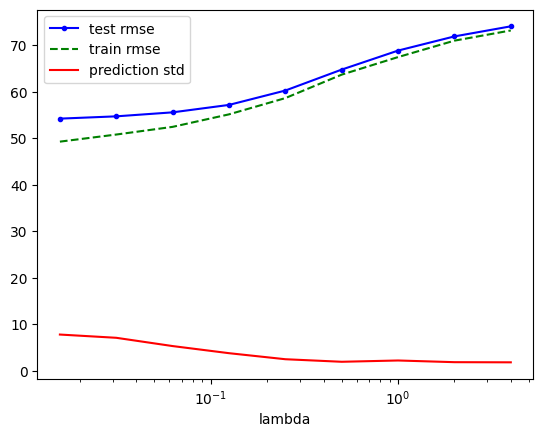

In [ ]:
# bias-variance trade-off
import random
from sklearn.linear_model import Ridge
import seaborn as sns

# Select regularization parameter using validation set (try using Lasso and Ridge)
alphas = [1/64, 1/32, 1/16, 1/8, 0.25, 0.5, 1, 2, 4]
ntrials = 100
rmse_test = np.zeros(len(alphas),)
rmse_train = np.zeros(len(alphas),)
std_pred = np.zeros(len(alphas),)
y_pred_all = np.zeros((len(y_test), ntrials))
nsamples = 50
for a in range(len(alphas)):
  for j in range(ntrials):
    ind = np.array(random.sample(range(370), k=nsamples))
    X_train_j = X.iloc[ind]
    y_train_j = y.iloc[ind]
    model = Ridge(alpha=alphas[a])
    model.fit(X_train_j, y_train_j)
    y_pred_j = model.predict(X_test)
    y_pred_tr = model.predict(X_train_j)
    y_pred_all[:,j] = y_pred_j
    rmse_test[a] += np.sqrt(np.mean((y_pred_j-y_test)**2)) / ntrials
    rmse_train[a] += np.sqrt(np.mean((y_pred_tr-y_train_j)**2)) / ntrials

  std_pred[a] = np.mean(np.var(y_pred_all, axis=1))/nsamples # var / nsamples)
print(std_pred.shape)
#print('alpha={:0.4f}: Val RMSE = {:.1f}'.format(alphas[i], rmse[i]))
plt.semilogx(alphas, rmse_test, 'b.-')
plt.semilogx(alphas, rmse_train, 'g--')
plt.semilogx(alphas, std_pred, 'r')
plt.legend(['test rmse', 'train rmse', 'prediction std'])
plt.xlabel('lambda')

### KNN

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import stats as st


(100, 2)


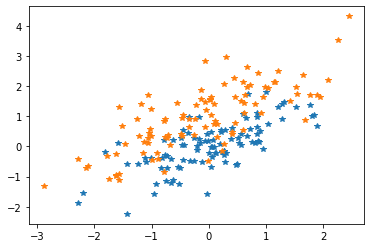

In [ ]:
# sample two classes from 2D gaussians with different means
# try KNN with Euclidean, Mahalanobis

mean = np.array([0, 0])
cov = np.array([[1, 0.75], [0.75, 1]])
a = np.random.multivariate_normal(mean, cov, size=(100,), check_valid='warn', tol=1e-8)
print(a.shape)
plt.plot(a[:,0], a[:,1], '*')
mean = np.array([0, 1])
b = np.random.multivariate_normal(mean, cov, size=(100,), check_valid='warn', tol=1e-8)
plt.plot(b[:,0], b[:,1], '*')